In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.decomposition import PCA
import umap
import pacmap
from xgboost import XGBClassifier
import shap
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans
import shapiq
from shapinteractions import ShapInteractions

/home/sbodin/melanoma_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading data

In [3]:
# DATA
df_sanger = pd.read_csv('Sanger/Dataset_sanger.csv')
df_responder = pd.read_csv('Sanger/Dataset_sanger_3g.csv')

# Merge sur les clefs
merge_cols = ['SANGER_MODEL_ID']
col_to_keep = merge_cols + ['DRUG_NAME', 'DRUG_ID', 'BRAF_Mut', 'is_responder']
df_50AUC = pd.merge(df_sanger, df_responder[col_to_keep], on=merge_cols, how='inner')


print(f"Shape APRES merge (avant nettoyage): {df_50AUC.shape}")

seuil_na = len(df_50AUC) * 0.90 
df_50AUC = df_50AUC.dropna(axis=1, thresh=seuil_na)

num_cols = df_50AUC.select_dtypes(include=[np.number]).columns
df_50AUC[num_cols] = df_50AUC[num_cols].fillna(df_50AUC[num_cols].median())

df_50AUC = df_50AUC.dropna(subset=['is_responder', 'BRAF_Mut'])

print(f"Shape final prêt pour l'analyse: {df_50AUC.shape}")
#print(df_50AUC.head())

# 2. Extraction features
meta_cols = ['SANGER_MODEL_ID', 'DRUG_NAME', 'DRUG_ID', 'BRAF_Mut', 'is_responder', 'model_name', 'data_source']
genes_columns = [c for c in df_50AUC.columns if c not in meta_cols]
X_genes = df_50AUC[genes_columns]

# Variance Threshold
selector_var = VarianceThreshold(threshold=0.8)
X_reduced = pd.DataFrame(
    selector_var.fit_transform(X_genes),
    columns=X_genes.columns[selector_var.get_support()],
    index=df_50AUC.index
)

X_final = X_reduced.copy()
X_final['BRAF_Mut'] = df_50AUC['BRAF_Mut'].values
X_final = X_final.dropna(axis=1)

print(f"X_final est prêt avec {X_final.shape[1]} features.")

Shape APRES merge (avant nettoyage): (23758, 36360)
Shape final prêt pour l'analyse: (23758, 31792)
X_final est prêt avec 3954 features.


In [6]:
# Afficher la moyenne d'IC50 et d'AUC pour chaque cluster
resume_clusters = df_responder.groupby('is_responder')[['LN_IC50', 'AUC']].mean()
print(resume_clusters)

               LN_IC50       AUC
is_responder                    
0             3.426860  0.916787
1             1.096831  0.747923


# Explanation

## Trametinib

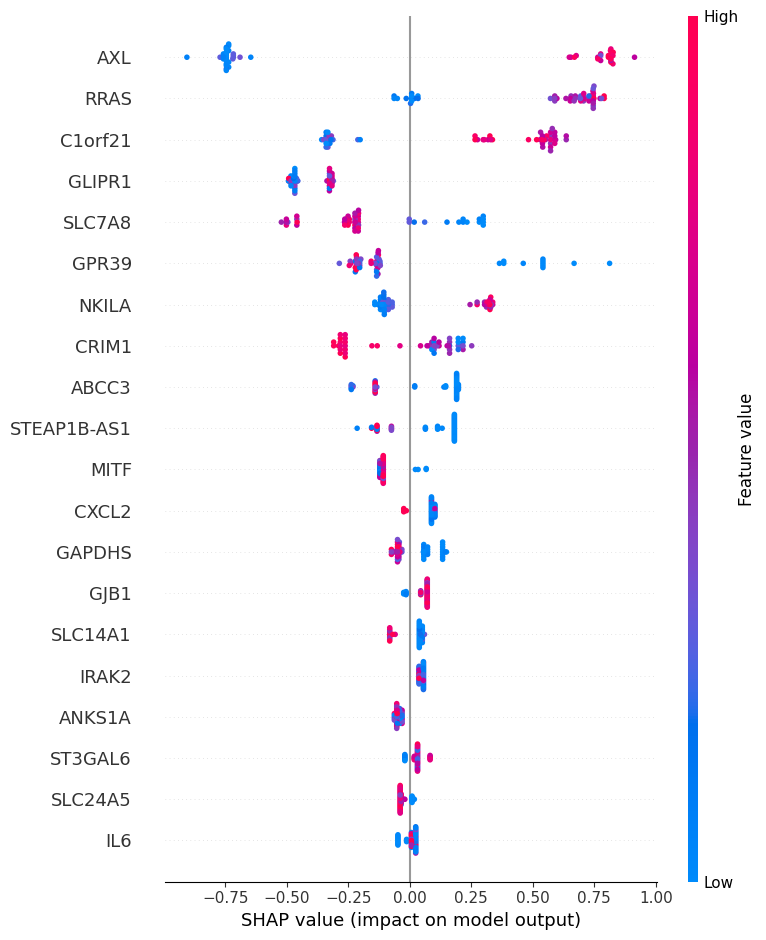

In [7]:
# Trametinib
model_Trametinib = joblib.load("models_test1/Trametinib.joblib")
xgb_model_Trametinib = model_Trametinib['model']
selected_genes_Trametinib = model_Trametinib['selected_features']

#features names 
xgb_model_Trametinib.get_booster().feature_names = selected_genes_Trametinib

#Mask
mask_Trametinib = df_50AUC['DRUG_NAME'] == 'Trametinib'
y_drug = df_50AUC.loc[mask_Trametinib, 'is_responder']
X_drug = X_final.loc[mask_Trametinib, selected_genes_Trametinib]

explainer = shap.TreeExplainer(xgb_model_Trametinib)
shap_values_Trametinib = explainer.shap_values(X_drug)

shap.summary_plot(shap_values_Trametinib, X_drug, max_display=20)

shap_matrix_Trametinib = shap_values_Trametinib

### Clustering SHAP Trame

/home/sbodin/melanoma_env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


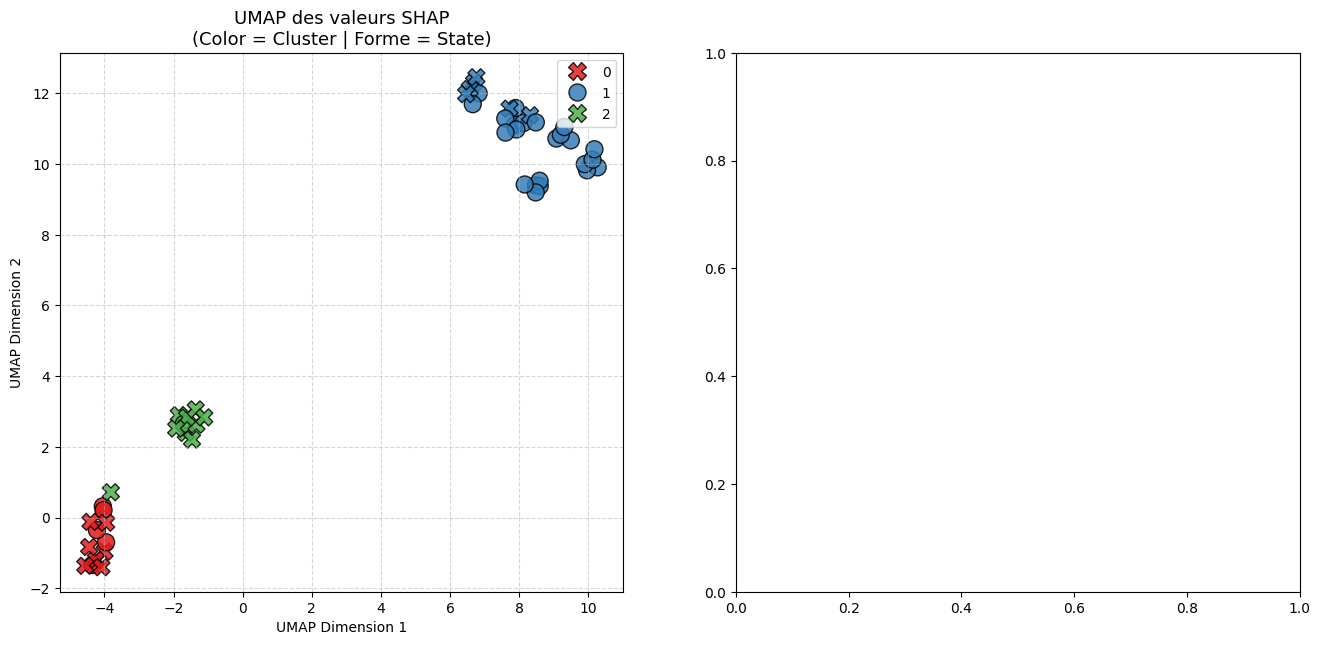

In [4]:
# Extraction du statut réel (0 ou 1)
labels_statut = y_drug.values if hasattr(y_drug, "values") else y_drug

# CLUSTERING
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_shap = kmeans.fit_predict(shap_matrix_Trametinib)

# PROJECTION NON-LINÉAIRE (UMAP)
reducer_umap = umap.UMAP(n_neighbors=12, min_dist=0.1, random_state=42)
X_umap = reducer_umap.fit_transform(shap_matrix_Trametinib)

# GrapH
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Graphique 1 : UMAP
sns.scatterplot(
    x=X_umap[:, 0], y=X_umap[:, 1],
    hue=clusters_shap,     
    style=labels_statut,
    palette="Set1",
    markers={0: "X", 1: "o"}, # Croix pour les résistants, ronds pour les sensibles
    s=150, edgecolor='black', alpha=0.85, ax=axes[0]
)
axes[0].set_title("UMAP des valeurs SHAP\n(Color = Cluster | Forme = State)", fontsize=13)
axes[0].set_xlabel("UMAP Dimension 1")
axes[0].set_ylabel("UMAP Dimension 2")
axes[0].grid(True, linestyle="--", alpha=0.5)

plt.show()

### SHAP IQ TRame

In [22]:
shapiq_value = X_drug.iloc[50].to_numpy()

explainer_trametinib_shapiq = shapiq.TreeExplainer(model=xgb_model_Trametinib, index="k-SII", min_order=1, max_order=2)

interaction_values_trametinib_shapiq = explainer_trametinib_shapiq.explain(shapiq_value)

interaction_values_trametinib_shapiq.values = np.nan_to_num(
    interaction_values_trametinib_shapiq.values, 
    nan=0.0, 
    posinf=0.0, 
    neginf=0.0
)

print(interaction_values_trametinib_shapiq)

InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=None,
    n_players=50, baseline_value=0.5044348715940027,
    Top 10 interactions:
        (): 0.5044348715940027
        (np.int64(2),): 0.49078199914174836
        (np.int64(14),): 0.44415562425931077
        (np.int64(45),): 0.3228167498006562
        (np.int64(37), np.int64(49)): 0.24283973154720112
        (np.int64(27),): 0.20093356269313742
        (np.int64(10),): 0.1380385245528636
        (np.int64(27), np.int64(45)): -0.18502418495938078
        (np.int64(26),): -0.20515076186506198
        (np.int64(40),): -0.23637870829721755
)


/home/sbodin/melanoma_env/lib/python3.9/site-packages/shapiq/explainer/tree/treeshapiq.py:270: RuntimeWarning: invalid value encountered in divide
  summary_poly_down[depth] = summary_poly_down[depth] / (self.D + p_e_ancestor)
/home/sbodin/melanoma_env/lib/python3.9/site-packages/shapiq/explainer/tree/treeshapiq.py:271: RuntimeWarning: invalid value encountered in divide
  quotient_poly_down[depth, interaction_sets] = quotient_poly_down[depth, interaction_sets] / (self.D + p_e_ancestor)
/home/sbodin/melanoma_env/lib/python3.9/site-packages/shapiq/explainer/tree/treeshapiq.py:272: RuntimeWarning: invalid value encountered in divide
  interaction_poly_down[depth, interaction_sets] = interaction_poly_down[depth, interaction_sets] / (-self.D + p_e_ancestor)
/home/sbodin/melanoma_env/lib/python3.9/site-packages/shapiq/explainer/tree/treeshapiq.py:400: RuntimeWarning: invalid value encountered in divide
  return ((E * D_power / quotient_poly)[:, :d]).dot(n) / d


(<Figure size 600x600 with 1 Axes>, <Axes: >)

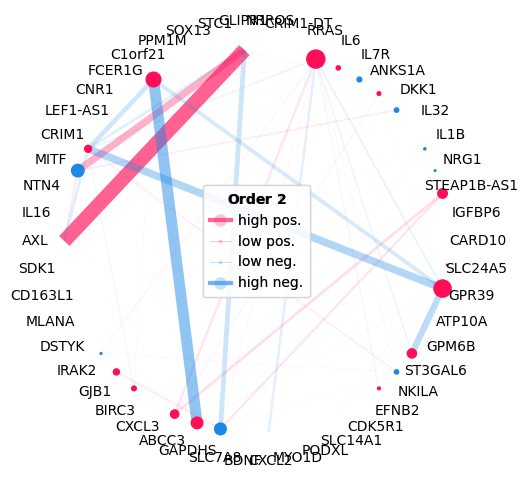

In [23]:
shapiq.network_plot(interaction_values=interaction_values_trametinib_shapiq, feature_names=list(X_drug.columns))

100%|██████████| 51/51 [00:02<00:00, 20.78it/s]


<Axes: xlabel='Attribution'>

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


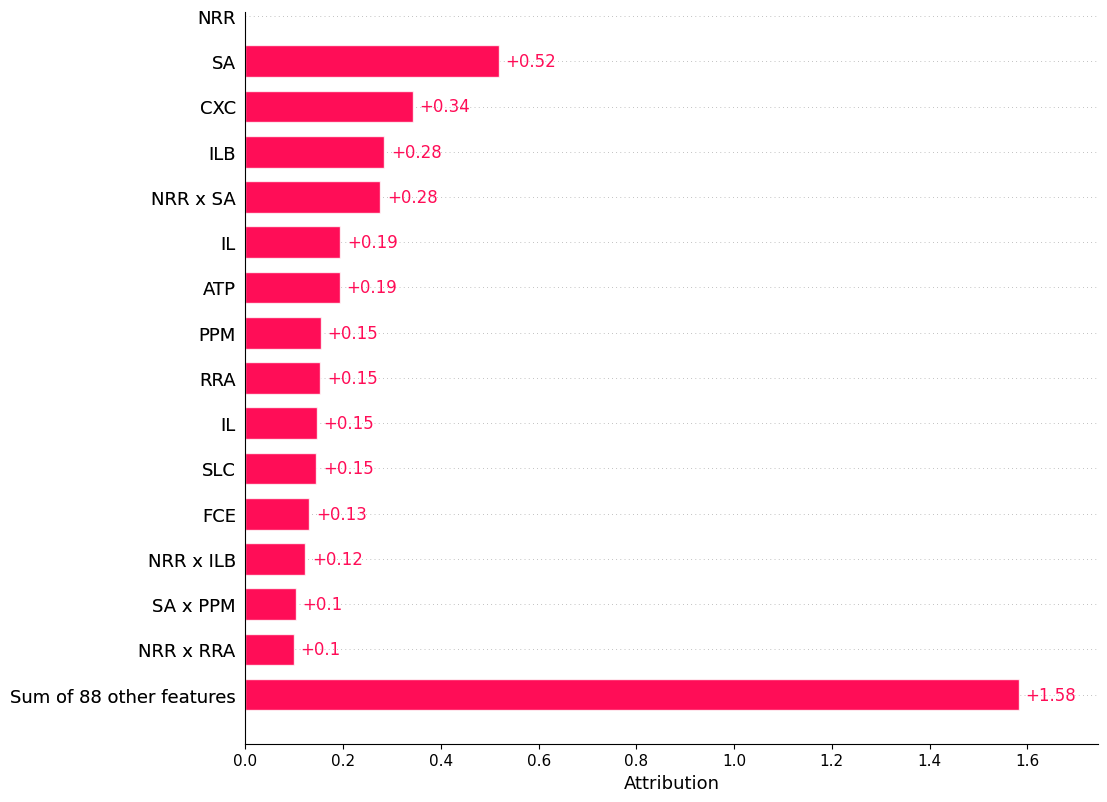

In [12]:
list_of_ivs_trametinib = explainer_trametinib_shapiq.explain_X(X_drug.values)

shapiq.plot.bar_plot(list_of_ivs_trametinib, feature_names=list(X_drug.columns), max_display=15)

### SHAPInteractions

In [12]:
X_drug_numpy = X_drug.to_numpy()
shap_interactions_trametinib = explainer.shap_interaction_values(X_drug)

interactions_trametinib = ShapInteractions(
    shap_interactions=shap_interactions_trametinib,
    feature_values=X_drug_numpy,
    feature_names=list(X_drug.columns),
    compute_correlations=False # change this to True to compute correlation coefficients as part of the initialization process
)

interactions_trametinib.compute_trend_coefs()

Computing Pearson's and Spearman's correlation coefficients... This may take time for large datasets. If found, NaNs will be ignored.


/home/sbodin/melanoma_env/lib/python3.9/site-packages/shapinteractions/interactions.py:117: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  self.pearsons[ind1, ind2], self.pval_pearsons[ind1, ind2] = pearsonr(x[valid_mask], y[valid_mask])
/home/sbodin/melanoma_env/lib/python3.9/site-packages/shapinteractions/interactions.py:118: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  self.spearmans[ind1, ind2], self.pval_spearmans[ind1, ind2] = spearmanr(x[valid_mask], y[valid_mask])


In [13]:
interactions_trametinib.create_graph(filename='interactions_trametinib_graph.html', spearmans_threshold=0.3)

In [8]:
# On isole l'expression du gène AXL
axl_expression = X_drug['AXL']
mediane_axl = axl_expression.median()

# On sépare nos cellules en deux groupes : AXL-high et AXL-low
cellules_axl_high = X_drug[axl_expression > mediane_axl]
cellules_axl_low = X_drug[axl_expression <= mediane_axl]

# On demande au modèle de prédire la PROBABILITÉ d'appartenir à la classe 1 (Sensible)
# predict_proba renvoie [probabilité_classe_0, probabilité_classe_1]
proba_sensible_axl_high = xgb_model_Trametinib.predict_proba(cellules_axl_high)[:, 1].mean()
proba_sensible_axl_low = xgb_model_Trametinib.predict_proba(cellules_axl_low)[:, 1].mean()

print(f"Probabilité moyenne d'être Sensible (Classe 1) si AXL est ÉLEVÉ : {proba_sensible_axl_high:.2%}")
print(f"Probabilité moyenne d'être Sensible (Classe 1) si AXL est FAIBLE : {proba_sensible_axl_low:.2%}")

Probabilité moyenne d'être Sensible (Classe 1) si AXL est ÉLEVÉ : 70.67%
Probabilité moyenne d'être Sensible (Classe 1) si AXL est FAIBLE : 43.55%


In [10]:
import scipy.stats as stats

# On extrait les vraies valeurs d'IC50 correspondantes
ic50_reels = df_responder.loc[mask_Trametinib, 'LN_IC50']

# Corrélation de Pearson entre l'expression d'AXL et le LN_IC50
corr, pval = stats.pearsonr(X_drug['AXL'], ic50_reels)

print(f"Corrélation directe AXL / LN_IC50 : {corr:.3f}")

Corrélation directe AXL / LN_IC50 : -0.104


## Refametinib

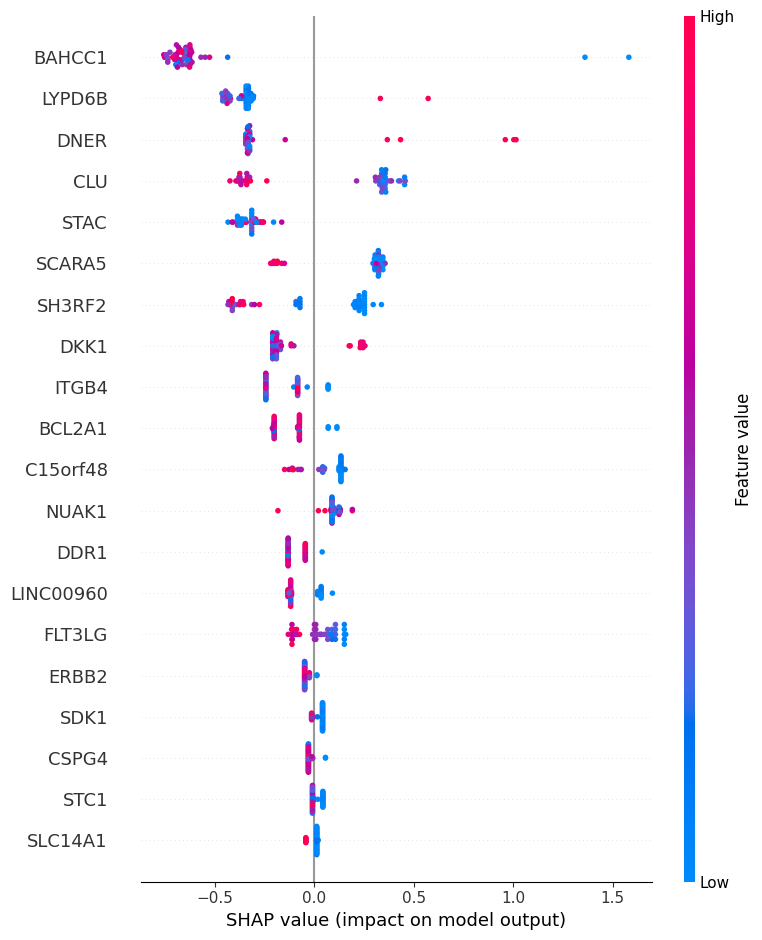

In [30]:
# Refametinib
model_Refametinib = joblib.load("models_test1/Refametinib.joblib")
xgb_model_Refametinib = model_Refametinib['model']
selected_genes_Refametinib = model_Refametinib['selected_features']

#features name
xgb_model_Refametinib.get_booster().feature_names = selected_genes_Refametinib

#Mask
mask_Refametinib = df_50AUC['DRUG_NAME'] == 'PLX-4720'
y_drug = df_50AUC.loc[mask_Refametinib, 'is_responder']
X_drug = X_final.loc[mask_Refametinib, selected_genes_Refametinib]

explainer = shap.TreeExplainer(xgb_model_Refametinib)
shap_values_Refametinib = explainer.shap_values(X_drug)

shap.summary_plot(shap_values_Refametinib, X_drug, max_display=20)

shap_matrix_Refametinib = shap_values_Refametinib

### Cluster SHAP

/home/sbodin/melanoma_env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


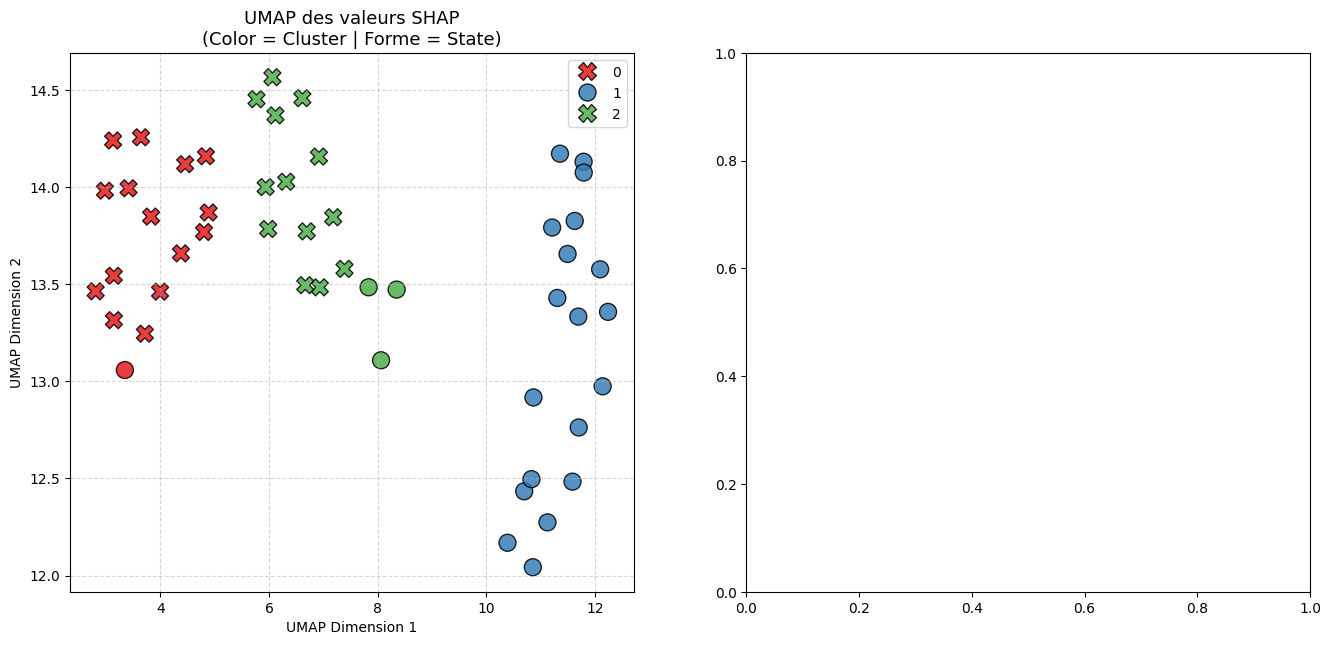

In [22]:
# Extraction du statut réel (0 ou 1)
labels_statut = y_drug.values if hasattr(y_drug, "values") else y_drug

# CLUSTERING
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_shap = kmeans.fit_predict(shap_matrix_Vemurafenib)

# PROJECTION NON-LINÉAIRE (UMAP)
reducer_umap = umap.UMAP(n_neighbors=12, min_dist=0.1, random_state=42)
X_umap = reducer_umap.fit_transform(shap_matrix_Vemurafenib)

# GrapH
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Graphique 1 : UMAP
sns.scatterplot(
    x=X_umap[:, 0], y=X_umap[:, 1],
    hue=clusters_shap,     
    style=labels_statut,
    palette="Set1",
    markers={0: "X", 1: "o"}, # Croix pour les résistants, ronds pour les sensibles
    s=150, edgecolor='black', alpha=0.85, ax=axes[0]
)
axes[0].set_title("UMAP des valeurs SHAP\n(Color = Cluster | Forme = State)", fontsize=13)
axes[0].set_xlabel("UMAP Dimension 1")
axes[0].set_ylabel("UMAP Dimension 2")
axes[0].grid(True, linestyle="--", alpha=0.5)

plt.show()

### SHAP INT

In [31]:
X_drug_numpy = X_drug.to_numpy()
shap_interactions_refametinib = explainer.shap_interaction_values(X_drug)

interactions_refametinib = ShapInteractions(
    shap_interactions=shap_interactions_refametinib,
    feature_values=X_drug_numpy,
    feature_names=list(X_drug.columns),
    compute_correlations=False 
)

interactions_refametinib.compute_trend_coefs()

Computing Pearson's and Spearman's correlation coefficients... This may take time for large datasets. If found, NaNs will be ignored.


/home/sbodin/melanoma_env/lib/python3.9/site-packages/shapinteractions/interactions.py:117: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  self.pearsons[ind1, ind2], self.pval_pearsons[ind1, ind2] = pearsonr(x[valid_mask], y[valid_mask])
/home/sbodin/melanoma_env/lib/python3.9/site-packages/shapinteractions/interactions.py:118: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  self.spearmans[ind1, ind2], self.pval_spearmans[ind1, ind2] = spearmanr(x[valid_mask], y[valid_mask])


In [32]:
interactions_refametinib.create_graph(filename='interactions_refametinib_graph.html', spearmans_threshold=0.3)

## Selumetinib

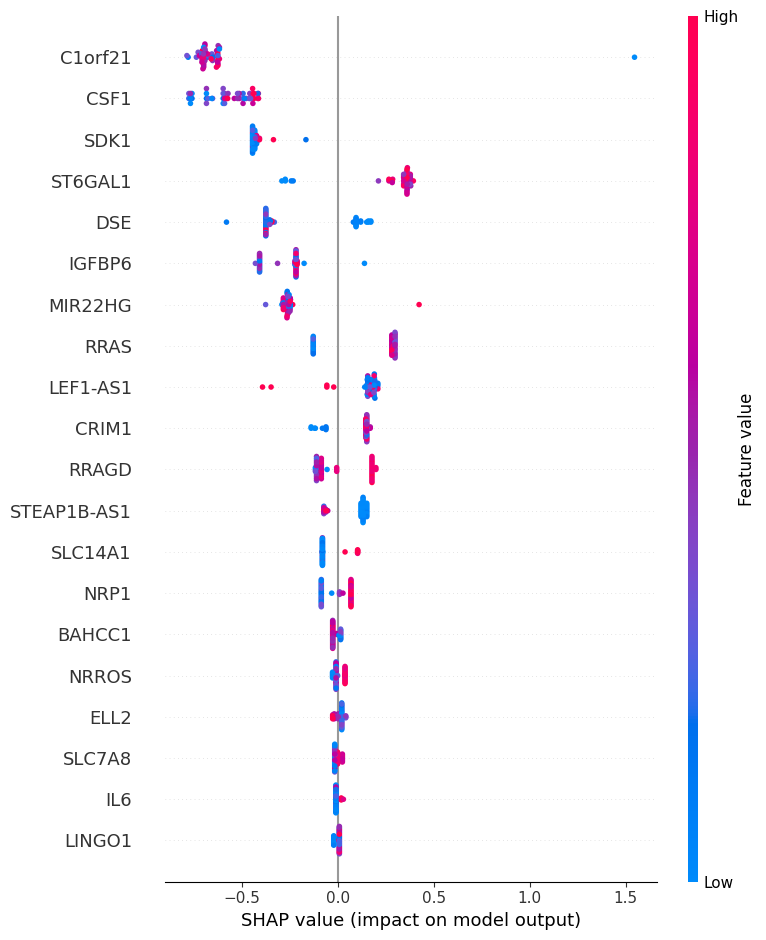

In [33]:
# Refametinib
model_Selumetinib = joblib.load("models_test1/Selumetinib.joblib")
xgb_model_Selumetinib = model_Selumetinib['model']
selected_genes_Selumetinib = model_Selumetinib['selected_features']

#features name
xgb_model_Selumetinib.get_booster().feature_names = selected_genes_Selumetinib

#Mask
mask_Selumetinib = df_50AUC['DRUG_NAME'] == 'PLX-4720'
y_drug = df_50AUC.loc[mask_Selumetinib, 'is_responder']
X_drug = X_final.loc[mask_Selumetinib, selected_genes_Selumetinib]

explainer = shap.TreeExplainer(xgb_model_Selumetinib)
shap_values_Selumetinib = explainer.shap_values(X_drug)

shap.summary_plot(shap_values_Selumetinib, X_drug, max_display=20)

shap_matrix_Selumetinib = shap_values_Selumetinib

In [35]:
X_drug_numpy = X_drug.to_numpy()
shap_interactions_selumetinib = explainer.shap_interaction_values(X_drug)

interactions_selumetinib = ShapInteractions(
    shap_interactions=shap_interactions_selumetinib,
    feature_values=X_drug_numpy,
    feature_names=list(X_drug.columns),
    compute_correlations=False 
)

interactions_selumetinib.compute_trend_coefs()

Computing Pearson's and Spearman's correlation coefficients... This may take time for large datasets. If found, NaNs will be ignored.


/home/sbodin/melanoma_env/lib/python3.9/site-packages/shapinteractions/interactions.py:117: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  self.pearsons[ind1, ind2], self.pval_pearsons[ind1, ind2] = pearsonr(x[valid_mask], y[valid_mask])
/home/sbodin/melanoma_env/lib/python3.9/site-packages/shapinteractions/interactions.py:118: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  self.spearmans[ind1, ind2], self.pval_spearmans[ind1, ind2] = spearmanr(x[valid_mask], y[valid_mask])


In [36]:
interactions_selumetinib.create_graph(filename='interactions_selumetinib_graph.html', spearmans_threshold=0.3)